In [1]:
!pip3 install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.3 MB/s eta 0:00:00


# **AutoEncoders and hidden states Analysis**

Привет, друзья!
В этом туториале мы разберем идею применения автокодировщиков для анализа и извлечения признаков из скрытых состояний модели.

В туториале, вы:

- Изучите или повторите, как работает извлечение признаков в Visual Transformers;
- Построите и примените автокодировщик для сжатия скрытых представлений, выученных моделью ViT в задаче классификации котиков и собачек;
- Сравните Vit и PCA в данной задаче.

Приступим!

### **Извлечение признаков в ViT**

Прежде чем понять анализ скрытых представлений, необходимо понять с чем мы будем работать. В работе с текстовым трансформером, которую я разбирала в туториале [Probing GPT model](https://habr.com/ru/articles/885076/) извлечение скрытых представлений базировалось на анализе векторных представлений слов.

Форма скрытых состояний для текстов была такой: (batch_size, sequence_length, hidden_dim). То есть для одного входа, например, для предложения из 6 токенов размерности были (1, 6, 1024) — 6 токенов, каждый представлен 1024-мерным вектором.

Таким образом, при работе с текстом, мы работаем с 1D векторами токенов какой-то фиксированной длины. Но что насчет изображений?

### **Изображения в признаки. Идея патчей**

Интуитивный и базовый подход представления изображения в виде, удобном для анализа и векторизации — взять изображение и сгладить его до 1D. Тогда, если изображение у нас 8x8, то при сглаживании получится вектор длины 64.

Но такой подход не оказывается рабочим, когд изображение чуть больше, скажем 64x64. Тогда его размерность в 1D уже 4096 и при этом каждый пиксель нужно будет связать с другим (то есть $4096^2$ связей).

И так, собирая задачи, мы хотим:
- Чтобы каждое изображение отражали несколько векторов;
- Чтобы каждый из векторов был фиксированной и адекватной (заданной нами) размерности;

**Патчи в ViT.**

В ViT (Visual Transformers) — одной из значимых архитектур 2021([статья](https://arxiv.org/abs/2010.11929)) решение этих задач реализовано при помощи патчей.

Патчи строятся так:

1. Берем картинку $H, W, C$ – высота, ширина, число каналов  (1)
2. Режем её на $N$ патчей. Каждый из патчей — это "квадрат" на изображении, с размерностями $p, p, c$, где $p$ — сторона квадрата (2)
3. Эти патчи разглаживаем  в вектор, выходит N векторов размерностью $p^2*C$ (3)
4. Массив патчей, размерностью $(N, p^2*C)$ умножается на обучаемый тензор
с размерностями  $(p^2*C, d)$  (4)
5. В результате получаем N патчей с размерностями $(1, d)$  (5)
6. Добавляем $[cls]$ токен, аналогичный BERT (картинка и интуитивный ответ [тут](https://stackoverflow.com/questions/62705268/why-bert-transformer-uses-cls-token-for-classification-instead-of-average-over), с размерностью $(1, d)$, итого у нас вход – $(N+1, d)$ патчей6)
6. В завершение каждому патчу добавляем позиционный эмбеддинг с такой-же размерностью $(1, d)$ (7)

И вот мы сварили признаки, которые далее проходят в слои энкодера.


![patches](https://user-images.githubusercontent.com/42609155/128160932-6c92920e-b996-4208-9f71-c5caeb4d7285.png)


**Сколько векторов на практике отражает изображение и какова их размерность?**

Размерность вектора параметров (то есть d в нотации выше) Vit — это фиксированный параметр. Стандартно, вектор имеет длину 768, таким образом, если входное изображение состоит из 1 канала и имеет размерности $(h, w) = (224, 224)$, то чтобы посчитать, сколько векторов будет его характеризовать, нужно выбрать:

1. Количество патчей для разбиения, $k$
2. Размер патчей, $p$

Количество и размер выбираем так, что $h=w=p\cdot k$. Тогда если патчей 14, как в примере, то количество векторов для кодирования изображения:

$$cnt = \frac{h}{p}*\frac{w}{p} = p * p = 14 * 14 = 196$$

Разбиение изображения осуществляется при помощи свертки с ядром $kernel=(p, p)$ и шагом (stride), таким что $stride=(p, p)$.

И вот, наше изображение будет представлено $197$ векторами ($196$ на патчи, плюс cls) размерностью $768$!

### **Практика**

Теперь, зная необходимое о формировании признаков, перейдем к практике.

In [3]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import os
import matplotlib.pyplot as plt
from io import BytesIO
import torch.nn as nn
import numpy as np
from tqdm import tqdm
from pillow_heif import register_heif_opener # для изображений в формате HEIC (1)

register_heif_opener() # для изображений в формате HEIC (2)

Теперь загрузим модель и картинку. Начнем с картинки. Это мои коты =).

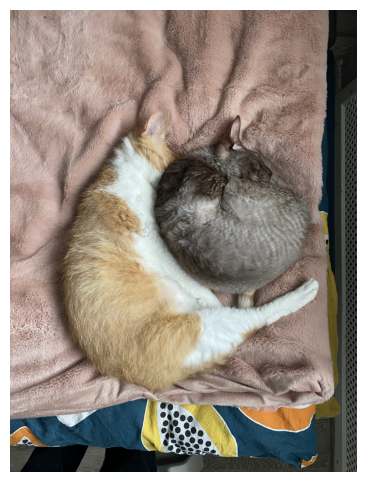

In [4]:
# Load Image
url = 'https://github.com/SadSabrina/XAI-open_materials/blob/main/VIT_and_autoencoders/IMG_8625.HEIC?raw=true'
image_bytes = requests.get(url).content
image = Image.open(BytesIO(image_bytes))
                   

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(image)
plt.axis('off');

Теперь модель и `ImageProcessor` для VIT моделей. Модель взята отсюда: https://huggingface.co/akahana/vit-base-cats-vs-dogs \
Вы можете загрузить модель с HF — такой вариант уже указан в коде. В случае если не выйдет, вам нужно:
1. скачать папку `cat_dog_model` по [ссылке](https://drive.google.com/drive/folders/1TztlM4sC0HRJmhZyMltRIGZP1exGRHt5?usp=sharing);
2.  указать папку с файлами в `MODEL_PATH`
3. выполнить загрузку.

In [6]:
MODEL_PATH = 'your_path_here'
MODEL_PATH_HF = 'akahana/vit-base-cats-vs-dogs'

# Загружаем предобученный feature extractor и классификационную модель
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
model = ViTForImageClassification.from_pretrained(MODEL_PATH_HF)
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

Пребразуем входную картинку в признаки при помощи `ViTImageProcessor`.

In [7]:
# Подготавливаем входные данные
inputs = feature_extractor(images=image, return_tensors="pt")


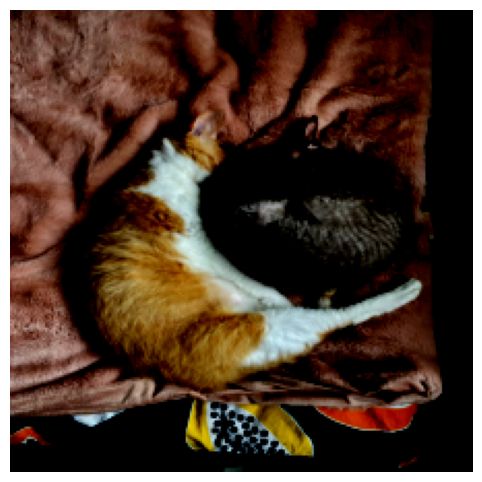

In [8]:
# изображение после взятия признаков

featured_image = inputs['pixel_values'][0].permute(1, 2, 0)

fig, ax = plt.subplots(figsize=(12, 6))
plt.imshow(featured_image)
plt.axis('off');

### **Шаг 1. Анализ структуры**

Прежде чем извлекать признаки, пусть мы уже знаем их размеры, нужно понять, откуда они будут вытащены. Для этого посмотрим на структуру модели.

Реализовывать само извлечение вручную нам не придется, поскольку скрытые состояния могут быть получены при помощи указании гиперпараметра при инференсе модели.

In [9]:
model.vit

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [12]:
model.classifier

# Попробуйте понять, сколько слоев в энкодере? Расскоментируйте код ниже, чтобы получить ответ
# print(len(model.vit.encoder._modules['layer']))

Linear(in_features=768, out_features=2, bias=True)

И так, основная модель состоит из последовательности энкодеров и классификатора. Давайте попробуем понять, что будут представлять собой hidden states.



In [13]:
# Делаем предсказание
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# Получаем спрогнозированный класс
predicted_class_idx = outputs.logits.argmax(-1).item()
labels = model.config.id2label  # Словарь индексов и классов

print(f"Предсказанный класс: {labels[predicted_class_idx]}")

Предсказанный класс: cat


In [14]:
print(f'Количество скрытых состояний: {len(outputs.hidden_states)}')
print(f'Размерность каждого состояния: {outputs.hidden_states[0].shape}')

Количество скрытых состояний: 13
Размерность каждого состояния: torch.Size([1, 197, 768])


Количество скрытых состояний равно 13, где

* Первое ('outputs.hidden_states[0]') — выход части эмбеддинга `model.vit.embeddings`
* Состояния 2-13 — выходы частей энкодера — все до применения к ним самого последнего слоя компоненты `model.vit` — `layernorm`

**Важно:**

В некоторых моделях, при указании `output_hidden_states=True` возвращается также `last_hidden_state`. В общем случае, `outputs.last_hidden_state != outputs.hidden_states[-1]`, так как то, что хранится в  `outputs.last_hidden_state` отражает скрытое состояние после `layernorm`

Теперь, поняв выход для одной картинки, мы можем прогнать несколько. Скажем 300 котиков и собачек (можно больше, если запускаете локально на хорошем ноутбуке).

In [15]:
# Указываем путь к папке с изображениями
image_folder = "/content/drive/MyDrive/Интерпретируемость и объяснимость в машинном и глубинном обучении (stepik)/HW_module15_advanced_methods/autoencoders_data/test_cats_dogs"


# Подготавливаем списки для данных
last_hidden_states_list = []
mid_hidden_states_list = []
labels_list = []

# Проходим по всем файлам в папке
for filename in tqdm(os.listdir(image_folder)[:300]):
    if filename.endswith((".jpg", ".png", ".jpeg")):  # Фильтруем изображения
        image_path = os.path.join(image_folder, filename)
        image = Image.open(image_path).convert("RGB")  # Открываем изображение

        # Обрабатываем изображение с помощью feature extractor
        inputs = feature_extractor(images=image, return_tensors="pt")

        # Получаем скрытые состояния
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            features = model.vit(**inputs).last_hidden_state[:, 1:, :] # представление изображения перед подачей в классификатор
            mid_features = outputs.hidden_states[len(outputs.hidden_states) // 2][:, 1:, :]  # Последний слой (размерность: batch x patches x hidden_dim)

        predicted_class_idx = outputs.logits.argmax(-1).item()
        labels = model.config.id2label  # Словарь индексов и классов
        label = labels[predicted_class_idx]

        # Добавляем скрытые состояния и метку в список
        last_hidden_states_list.append(features.squeeze(0))  # Убираем batch размерность
        mid_hidden_states_list.append(mid_features.squeeze(0))
        labels_list.append(label)



100%|██████████| 300/300 [08:17<00:00,  1.66s/it]


In [16]:
# Преобразуем в тензоры
last_hidden_states_tensor = torch.stack(last_hidden_states_list)  # Размерность: (num_images, hidden_dim)

mid_hidden_states_tensor = torch.stack(mid_hidden_states_list)

Теперь, подытожим, что мы имеем. На каждую картинку из 300 у нас есть матрица $197x768$. В таком формате анализировать признаки и как-то разделить их для двух классов не удобно.  Как понять, разделила ли модель классы в пространстве?

Для этого мы можем применить автокодировщик!


### **Автокодировщик, краткая справка**

**Автокодировщики (автоэнкодеры)** — это нейронные сети особой архитектуры, ключевая компонента которых — сжатие признаков в скрытое пространство. Изначально это скрытое пространство, конечно, не предназначалось для области XAI (да и в 1986 году, когда идея автокодировщиков была описана, проблемы черных ящиков не было), но последние исследования [OpenAI](https://openai.com/index/extracting-concepts-from-gpt-4/)(и не только) показали потенциал этой архитектуры в области интерпретируемости.

Простейший автокодировщик выглядит [так](https://en.wikipedia.org/wiki/Autoencoder) (wiki link).


 Реализуем его в коде в виде двух компонент, как на картинке — энкодера и декодера. Для них напишем простые классы из такой логики.

У нас 196 патчей по 768 признаков. Количество патчей — это наше колиечество признаков, его урезать некорректно, поэтому будем работать с размерностью скрытого представления — 768.

In [17]:
class PatchEncoder(nn.Module):
    def __init__(self, D_latent=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(768, 512, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(512, 256, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(256, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(8, 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(4, D_latent, kernel_size=1), # [B, 196, D_latent].

        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, 768, 196] для Conv1d
        return self.encoder(x).permute(0, 2, 1)  # [B, 196, D_latent]


class PatchDecoder(nn.Module):
    def __init__(self, D_latent=128):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv1d(D_latent, 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(4, 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=1),  # Восстанавливаем размерность
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(256, 512, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(512, 768, kernel_size=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, D_latent, 196]
        return self.decoder(x).permute(0, 2, 1)  # [B, 196, 768]


class PatchAutoencoder(nn.Module):
    def __init__(self, D_latent=128):
        super().__init__()
        self.encoder = PatchEncoder(D_latent)
        self.decoder = PatchDecoder(D_latent)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Модель готова. В ней мы последовательно уменьшаем признаки с помощью свертки. При применении автокодировщика к скрытым состониям идея такова:

*если автокодироващик сможет при обучении сойтись, то мы получим представление, отражающее сжатые признаки из модели*.

Ну хорошо. Теперь подготовим данные и обучим автоэнкодер.

### **Подготовка данных**

При извлечении признаков будем опираться не на ground truth классы, а не те, что спрогнозировала модель. Их мы собрали выше.

**Почему именно так?** \
Постановка задачи извлечения признаков всегда связана с извлечением информации *из модели*, а значит корректно опираться только на ту информацию, которая заложена в ней. При анализе признаков гипотеза такова — спрогнозированный класс соответствует "мнению" модели на основе её знаний об изображении.

In [18]:
# Подготовка классов

func = lambda x: 1 if x =='cat' else 0
inv_func = lambda x: 'cat' if x == 1 else 'dog'

labels_list = [func(i) for i in labels_list]

In [19]:
labels_tensor = torch.tensor(labels_list)  # Размерность: (num_images,)

# Сохраняем скрытые состояния и метки, чтобы каждый раз не получать их заново
torch.save(last_hidden_states_tensor, "last_hidden_states.pt")
torch.save(mid_hidden_states_tensor, "mid_last_hidden_states.pt")

torch.save(labels_tensor, "labels.pt")

print(f"Сохранено {len(last_hidden_states_tensor)} скрытых состояний. Размер тензора: {last_hidden_states_tensor.shape}")
print(f"Сохранено {len(mid_hidden_states_tensor)} скрытых состояний. Размер тензора: {mid_hidden_states_tensor.shape}")

Сохранено 300 скрытых состояний. Размер тензора: torch.Size([300, 196, 768])
Сохранено 300 скрытых состояний. Размер тензора: torch.Size([300, 196, 768])


Запуск обучения на скрытых состояниях. Выше мы собрали два последнее (в `last_hidden_states_list`) и среднее (в `mid_hidden_states_list`)

In [20]:
autoencoder = PatchAutoencoder(D_latent=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = autoencoder(last_hidden_states_tensor)  # [B, 196, 768]
    loss = criterion(outputs, last_hidden_states_tensor)
    loss.backward()
    optimizer.step()
    print(loss)

tensor(0.0452, grad_fn=<MseLossBackward0>)
tensor(0.0451, grad_fn=<MseLossBackward0>)
tensor(0.0450, grad_fn=<MseLossBackward0>)
tensor(0.0449, grad_fn=<MseLossBackward0>)
tensor(0.0448, grad_fn=<MseLossBackward0>)
tensor(0.0447, grad_fn=<MseLossBackward0>)
tensor(0.0446, grad_fn=<MseLossBackward0>)
tensor(0.0445, grad_fn=<MseLossBackward0>)
tensor(0.0444, grad_fn=<MseLossBackward0>)
tensor(0.0444, grad_fn=<MseLossBackward0>)


Судя по уменьшению лосса, обучение прошло. Оно, конечно, не значимо ушло от начальной точки, но результат имеет смысл проверить.

Теперь извлечем скрытые представления и возьмём медиану по патчам, чтобы получить матрицу $m \times n$, где $m$ — число строк (примеров), а $n$ — медиана каждого патча.  

In [21]:
latent = autoencoder.encoder(last_hidden_states_tensor)
latent_med = np.median(latent.detach().numpy(), axis=1)
latent_med.shape

(300, 2)

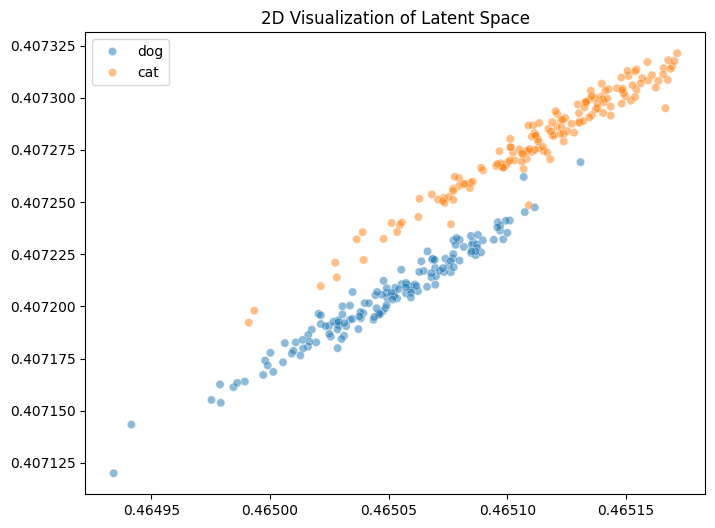

In [22]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=latent_med[:, 0], y=latent_med[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

Теперь посмотрим, будет ли такое же четкое разделение на средних скрытых слоях.

In [23]:
# Middle patches

mid_autoencoder = PatchAutoencoder(D_latent=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-2)
num_epochs = 10

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mid_autoencoder(mid_hidden_states_tensor)  # [B, 196, 768]
    loss = criterion(outputs, mid_hidden_states_tensor)
    loss.backward()
    optimizer.step()
    print(loss)

tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)


In [24]:
mid_latent = mid_autoencoder.encoder(mid_hidden_states_tensor)
mid_latent_med = np.median(mid_latent.detach().numpy(), axis=1)
mid_latent_med.shape

(300, 2)

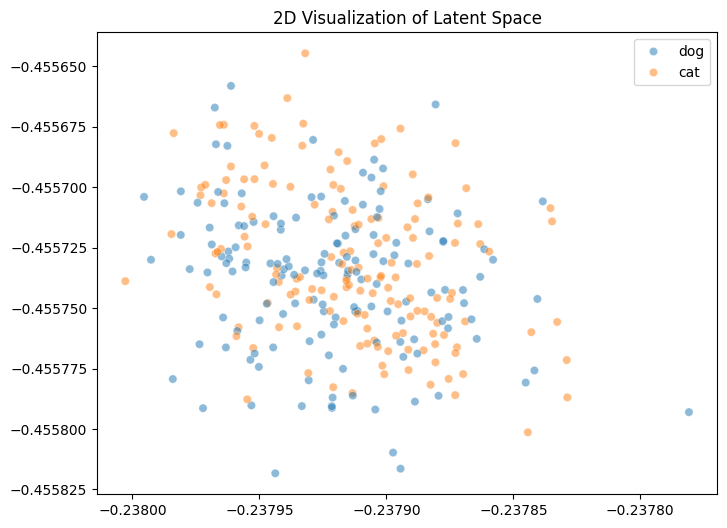

In [25]:
# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=mid_latent_med[:, 0], y=mid_latent_med[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

На средних слоях видим только начало разделения, кроме того, процесс обучения AE не идет.

### **Результаты и выводы**

Зафиксируем, что получилось.

1. Сначала была взята обученная модель.

2. На тестовых данных для этой модели были извлечены:

* прогнозы;
* скрытые состояния последнего слоя;
* скрытые состояния среднего слоя;

3. На скрытых состояниях был обучен автокодировщик, с центральной размерностью между encoder и decoder компонетами равной 2.

4. Представление в виде двух компонент мы использовали для оценки того, насколько разделены друг относительно друга признаки классов, которые прогнозирует модель  (в виде двух, потому что так его можно нарисовать на плоскости).

Визуализации показали, что модель хорошо разделяет признаковые представления на последнем скрытом состоянии и практически не разделяет на среднем. Из этого можно выдвинуть гипотезу о постепенном выделении при уточнении глубины сети (причем средний слой достаточно плохо разделяет классы).


**Примечание:**

На самом деле, вывод этого частного исследования нельзя обобщать для всех моделей и предполагать, что серединные hidden states не кодируют богатые представления. Напротив, например, тут [Layer by Layer: Uncovering Hidden Representations in Language Models](https://arxiv.org/pdf/2502.02013) авторы показывают, что промежуточные слои могут кодировать даже более богатые представления, чем последние, показывая хорошую производительность в широком диапазоне подзадач. Ещё интересный пример, здесь [Probing Latent Subspaces in LLM for AI Security: Identifying and Manipulating Adversarial States](https://arxiv.org/pdf/2503.09066) извлекают направление, дающее джейлбрейк, также с промежуточного слоя.

Внутри много интересного =).


Надеюсь, туториал будет некоторым вдохновением, показывающим, что работа с обученной сетью может быть полна на предмет анализа модели!


Благодарю за ваше время!
Как всегда, туториал на гитхаб (там же ноутбуки и другие туториалы в репозитории).


 **Успешных вам проектов!**
**Ваш Дата-автор!**



### **Заметка на полях - PCA**

Давайте рассмотрим, действительно ли нам нужен автоэнкодер.

Анализ главных компонент (PCA) - еще один эффективный метод снижения размерности, который можно было бы применить в этом контексте, особенно если мы пытаемся упростить представление скрытых состояний. PCA - это линейный метод, который проецирует данные в пространство, где дисперсия данных максимальна вдоль новых осей, что делает его хорошим кандидатом для определения наиболее информативных компонентов в пространстве признаков.

Вот почему PCA мог бы быть хорошей альтернативой автоэнкодеру:

1. **Простота**: PCA прост и эффективен с точки зрения вычислений. В отличие от автоэнкодеров, которые требуют обучения, PCA можно применять непосредственно к матрице признаков с минимальной подготовкой.

2. **Интерпретируемость**: PCA предоставляет компоненты, которые напрямую соответствуют направлениям максимальной дисперсии в пространстве признаков.

3. **Уменьшение размерности**: Как и автоэнкодер, PCA может уменьшать размерность пространства признаков. Разница в том, что PCA делает это линейно, тогда как автоэнкодер способен улавливать нелинейные связи в данных. Однако линейные методы, такие как PCA, могут по-прежнему работать достаточно хорошо, если данные линейно разделимы.

4. **Время и ресурсы**: PCA не требует обучения, что экономит время и вычислительные ресурсы по сравнению с обучением автоэнкодера, особенно если набор данных большой.

В случае скрытых состояний из модели трансформатора применение PCA может помочь уменьшить сложность данных и потенциально выявить четкие разделения между классами. Проецируя данные в пространство с меньшей размерностью (тоже два или три компонента), мы можем построить график данных и визуально проверить разделимость между классами, как мы пытались сделать с автоэнкодером.

В целом, всегда, прежде чем углубляться в сложность обучения автокодировщика, было бы полезно попробовать PCA как более простой базовый метод для понимания структуры данных. Результаты PCA могут быть сопоставимы с результатами автокодировщика, особенно когда мы пытаемся разделить классы на основе представлений признаков.

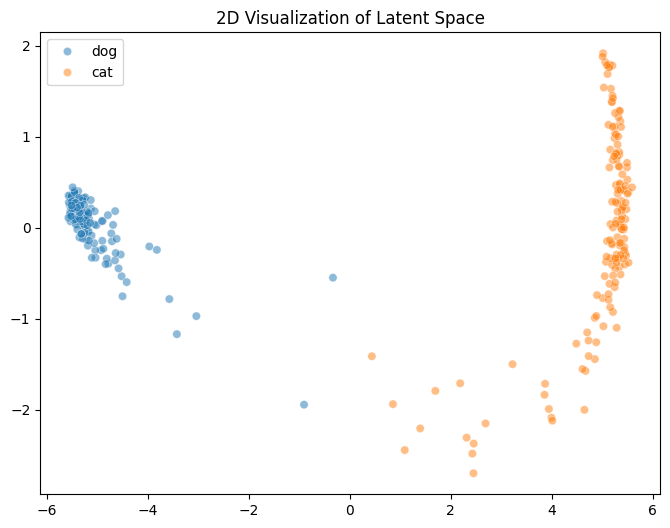

In [26]:
import seaborn as sns
from sklearn.decomposition import PCA

original_hid_states = np.median(last_hidden_states_tensor.detach().numpy(), axis=1)

pca = PCA(n_components=2, random_state=42)
orig_latent_2d = pca.fit_transform(original_hid_states)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=orig_latent_2d[:, 0], y=orig_latent_2d[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.legend()
plt.title("2D Visualization of Latent Space")
plt.show()

In [27]:
pca.explained_variance_ratio_

array([0.8817762 , 0.02155441], dtype=float32)

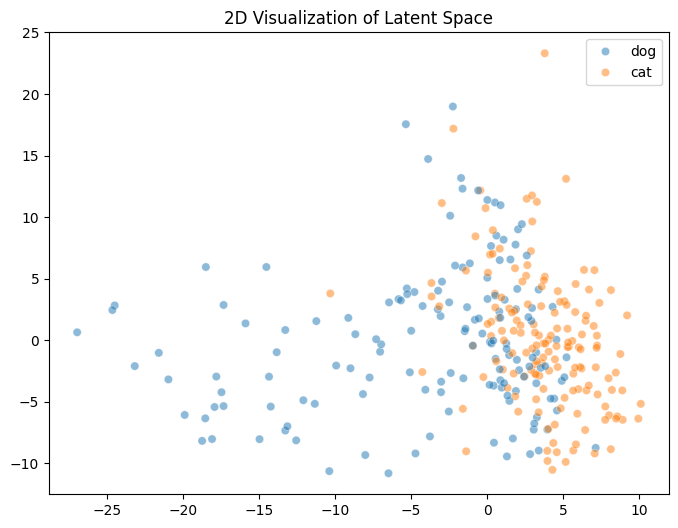

In [28]:
mid_original_hid_states = np.median(mid_hidden_states_tensor.detach().numpy(), axis=1)

pca = PCA(n_components=2, random_state=42)
mid_orig_latent_2d = pca.fit_transform(mid_original_hid_states)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=mid_orig_latent_2d[:, 0], y=mid_orig_latent_2d[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.legend()
plt.title("2D Visualization of Latent Space")
plt.show()

In [29]:
pca.explained_variance_ratio_

array([0.10040888, 0.06792985], dtype=float32)

Результат показывает, что важно помнить традиционные методы, особенно при работе с более простыми моделями и задачами.

Аавтоэнкодеры, предлагают мощные возможности нелинейного снижения размерности, но классические методы, такие как PCA, t-SNE или линейный дискриминантный анализ (LDA), иногда могут предоставлять эффективные решения, особенно когда проблема не требует полной сложности автокодировщиков.

Для таких задач, как извлечение признаков и разделение классов, где отношения могут быть относительно простыми, классические методы могут сэкономить время и вычислительные ресурсы, предоставляя прозрачное и интерпретируемое представление данных. Они также служат отличной базой, которая помогают проверить, действительно ли необходимы более сложные модели или достаточно ли более простых методов для эффективного решения проблемы.

Второй важный урок: всегда учитывайте баланс между сложностью и интерпретируемостью, особенно при работе с более простыми моделями или наборами данных, и помните о традиционных методах как о полезных инструментах для анализа и понимания.

Как всегда присоединяйтесь к [каналу в телеграм](https://t.me/jdata_blog), чтобы видеть новые выпуски! 😌

Также приглашаю пройти мой [курс](https://stepik.org/a/198640) по методам explainable AI и, конечно, буду рада видеть в [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).

Успешных и безумно красиовых вам проектов!
Ваш Дата-автор!